# CALoRa Detection Rate vs SNR — Comparison Plot

Select which result CSV files to overlay on a single graph.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

results_dir = os.path.join('.', 'results')

# List all available CSV files
all_csvs = sorted(glob.glob(os.path.join(results_dir, 'calora_results_*.csv')))
print(f'Available result files in {results_dir}:')
for i, f in enumerate(all_csvs):
    print(f'  [{i}] {os.path.basename(f)}')

Available result files in .\results:
  [0] calora_results_20260806_ori.csv
  [1] calora_results_20260806_ori_cfo.csv
  [2] calora_results_20260806_ori_sto.csv
  [3] calora_results_20260806_ori_sto_cfo.csv
  [4] calora_results_20260806_sean.csv
  [5] calora_results_20260806_sean_cfo.csv
  [6] calora_results_20260806_sean_sto.csv
  [7] calora_results_20260806_sean_sto_cfo.csv
  [8] calora_results_20260806_ys.csv
  [9] calora_results_20260806_ys_cfo.csv
  [10] calora_results_20260806_ys_sto.csv
  [11] calora_results_20260806_ys_sto_cfo.csv


In [54]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    'conventional_results_20260806_101755.csv',
    'calora_results_20260806_ori.csv',
    'calora_results_20260806_sean.csv',
    'calora_results_20260806_ys.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_101755.csv
✅ calora_results_20260806_ori.csv
✅ calora_results_20260806_sean.csv
✅ calora_results_20260806_ys.csv


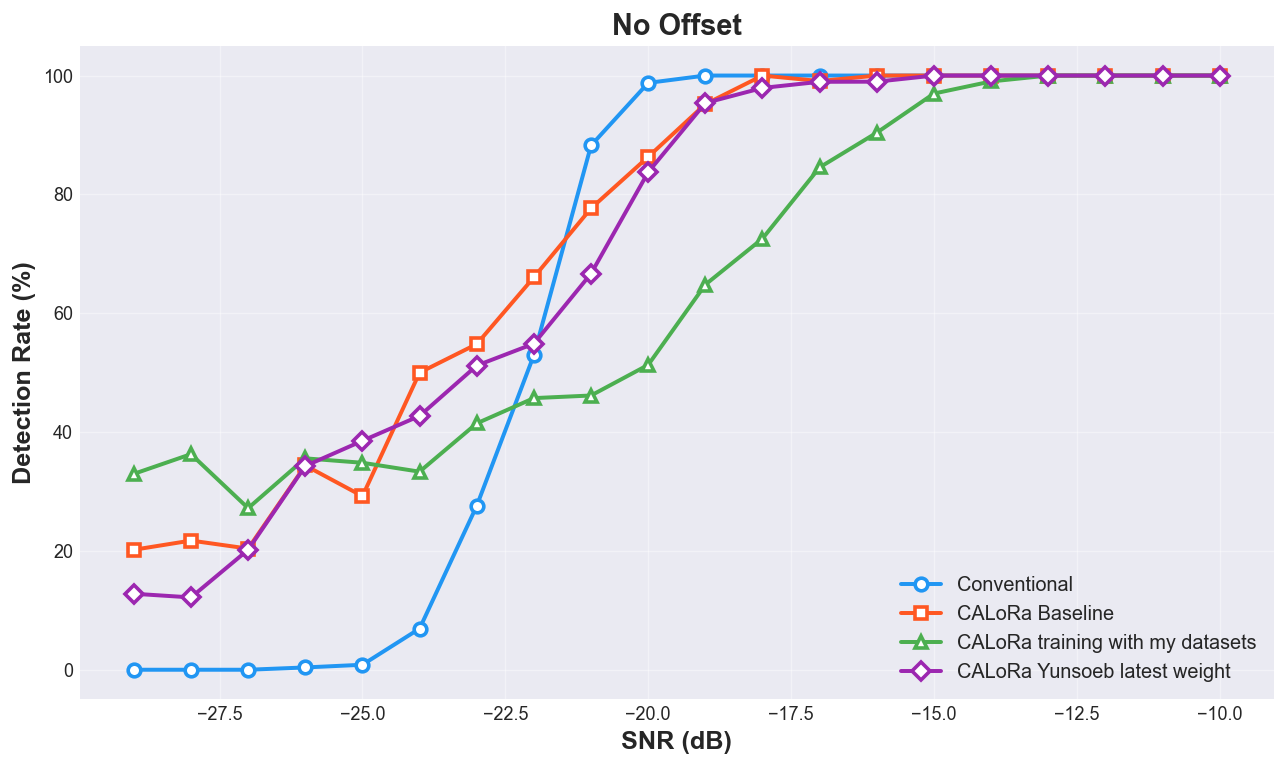


Plot saved to results/detrate_vs_snr_comparison.png


In [55]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('No Offset', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_vs_snr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved to results/detrate_vs_snr_comparison.png')

In [56]:
selected_files = [
    'conventional_results_20260806_cfo.csv',
    'calora_results_20260806_ori_cfo.csv',
    'calora_results_20260806_sean_cfo.csv',
    'calora_results_20260806_ys_cfo.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_cfo.csv
✅ calora_results_20260806_ori_cfo.csv
✅ calora_results_20260806_sean_cfo.csv
✅ calora_results_20260806_ys_cfo.csv


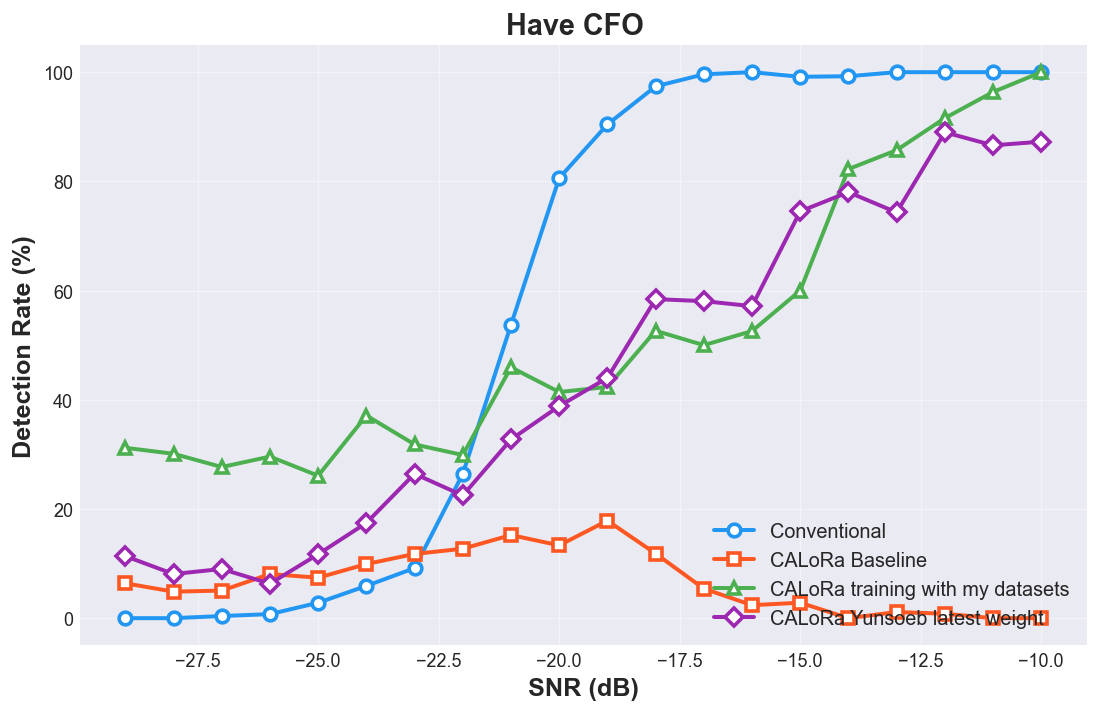

In [57]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Have CFO  ', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

In [58]:
selected_files = [
    'conventional_results_20260806_sto.csv',
    'calora_results_20260806_ori_sto.csv',
    'calora_results_20260806_sean_sto.csv',
    'calora_results_20260806_ys_sto.csv'
    
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_sto.csv
✅ calora_results_20260806_ori_sto.csv
✅ calora_results_20260806_sean_sto.csv
✅ calora_results_20260806_ys_sto.csv


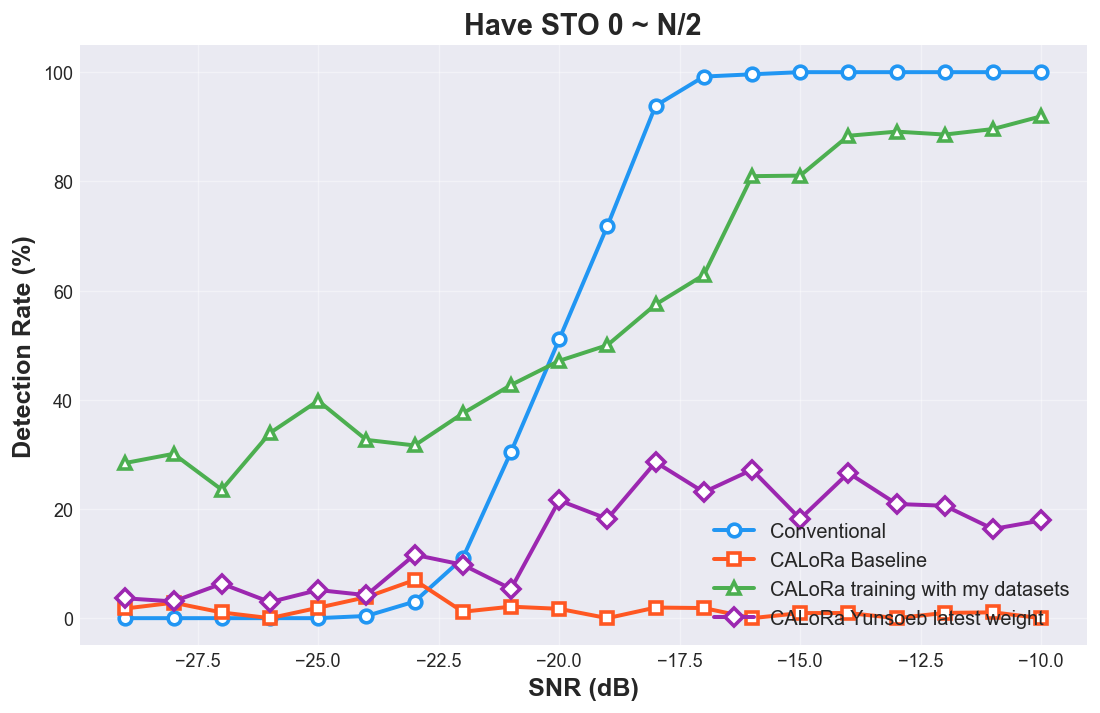

In [59]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Have STO 0 ~ N/2', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

In [60]:
selected_files = [
    'conventional_results_20260806_sto_cfo.csv',
    'calora_results_20260806_ori_sto_cfo.csv',
    'calora_results_20260806_sean_sto_cfo.csv',
    'calora_results_20260806_ys_sto_cfo.csv'
    
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_sto_cfo.csv
✅ calora_results_20260806_ori_sto_cfo.csv
✅ calora_results_20260806_sean_sto_cfo.csv
✅ calora_results_20260806_ys_sto_cfo.csv


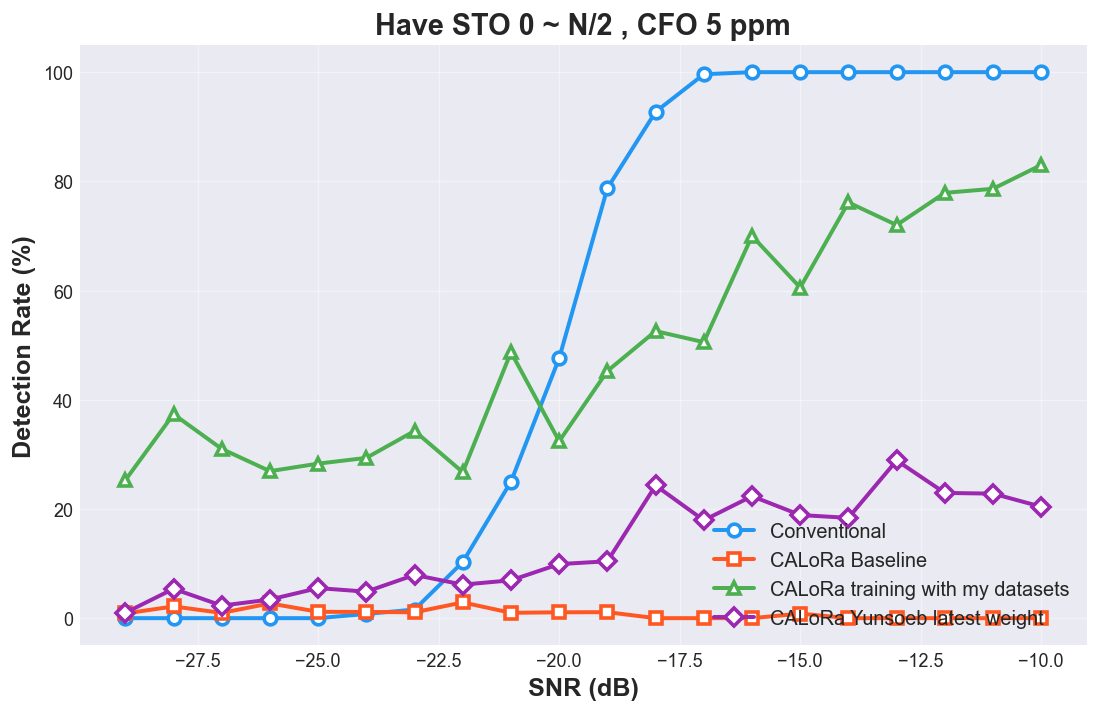

In [61]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Have STO 0 ~ N/2 , CFO 5 ppm', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

---

# CFO Accuracy & Symbol Decoding Accuracy vs SNR

The four sections above plot **DetRate** (preamble detection) only, because the files in
`results/` carry just two columns: `SNR,DetRate`.

CFO accuracy and symbol decoding accuracy live in the newer CSV format written by
`main.py` (conventional chain) and `main3.py` (CALoRa chain):

| folder | written by | columns |
|---|---|---|
| `results/` | older runs | `SNR,DetRate` only - **cannot** answer these two plots |
| `temp_results/` | `main.py` (conventional detection + conventional offset) | full set |
| `results3/` | `main3.py` (CALoRa detection + conventional offset) | full set |

All three folders are searched below, so a legacy file can sit in the same selection list -
it is skipped with a note rather than crashing the cell.

**Success is a tolerance, not an exact match:** CFO counts as correct when the error is
within half a frequency bin (488 Hz at SF7/BW125k); symbol accuracy is the fraction of
payload symbols demodulated correctly.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

ACC_DIRS = [os.path.join('.', 'temp_results'),
            os.path.join('.', 'results3'),
            os.path.join('.', 'results')]

ACC_FILES = {}
for d in ACC_DIRS:
    for f in sorted(glob.glob(os.path.join(d, '*.csv'))):
        ACC_FILES.setdefault(os.path.basename(f), f)

for d in ACC_DIRS:
    found = sorted(glob.glob(os.path.join(d, '*.csv')))
    has_acc = 0
    for f in found:
        if 'CFO_SuccessRate' in open(f).readline():
            has_acc += 1
    print(f'{d}  -  {len(found)} files, {has_acc} with CFO/Symbol columns')
    for f in found:
        mark = '  *' if 'CFO_SuccessRate' in open(f).readline() else '   '
        print(f'  {mark} {os.path.basename(f)}')

# ===================================================================
#   EDIT HERE: the files to overlay  ('*' above = has the columns)
# ===================================================================
acc_files = [
    'conventional_cfo_125.csv',
    'conventional_cfo_1m.csv',
    'offset_demod_results_20260820_cfo.csv',
]

acc_labels = [
    'Conventional, fs = 125 kHz',
    'Conventional, fs = 1 MHz',
    'CALoRa + conv offset, fs = 1 MHz',
]

# 'conditioned' -> denominator is packets that reached the stage
# 'per_packet'  -> denominator is every packet sent (preamble misses count as wrong)
ACC_SCOPE = 'per_packet'

print()
for fname in acc_files:
    print(('  OK   ' if fname in ACC_FILES else '  MISSING  ') + fname)

.\temp_results  -  19 files, 10 with CFO/Symbol columns
    * conventional_cfo_125.csv
    * conventional_cfo_1m.csv
      conventional_results_20260814_174248.csv
      conventional_results_20260814_174346.csv
      conventional_results_20260821_101757_cfo1.csv
      conventional_results_20260821_101843_cfo1.csv
      conventional_results_20260821_101854_cfo1.csv
      conventional_results_20260821_101925_cfo0.csv
      conventional_results_20260821_101938_cfo1.csv
      conventional_results_20260821_102045_cfo0.csv
      conventional_results_20260821_102058_cfo0.csv
    * conventional_results_20260821_102624_cfo1.csv
    * conventional_results_20260821_102638_cfo1.csv
    * conventional_results_20260821_103231_cfo1.csv
    * conventional_results_20260821_103247_cfo1.csv
    * conventional_results_20260821_103315_cfo1.csv
    * conventional_results_20260821_103536_cfo1.csv
    * conventional_results_20260821_103558_cfo1.csv
    * conventional_results_20260821_105416_cfo1.csv
.\results

In [63]:
# -- Shared plotting helper for the two figures below -----------------
ACC_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
ACC_COLORS  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']

ACC_COLUMNS = {
    'conditioned': {'cfo': 'CFO_SuccessRate', 'sym': 'SymbolAccuracy'},
    'per_packet':  {'cfo': 'CFO_SuccessRatePerPacket', 'sym': 'SymbolAccuracyPerPacket'},
}


def plot_accuracy(key, ylabel, title, outfile, threshold=90.0):
    column = ACC_COLUMNS[ACC_SCOPE][key]
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=130)
    plotted = 0

    for i, fname in enumerate(acc_files):
        path = ACC_FILES.get(fname)
        if path is None:
            print(f'  skipped {fname}: file not found')
            continue

        df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
        if column not in df.columns:
            print(f'  skipped {fname}: no {column} column (legacy SNR/DetRate file)')
            continue

        lbl = acc_labels[i] if i < len(acc_labels) and acc_labels[i] else fname.replace('.csv', '')
        color = ACC_COLORS[i % len(ACC_COLORS)]
        ax.plot(
            df['SNR'], df[column],          # already 0-100 in the CSV
            marker=ACC_MARKERS[i % len(ACC_MARKERS)],
            markersize=7, linewidth=2.2,
            color=color,
            markerfacecolor='white', markeredgewidth=2,
            markeredgecolor=color,
            label=lbl
        )
        plotted += 1

    if plotted == 0:
        print('  nothing plotted - none of the selected files carry that column')

    if threshold is not None:
        ax.axhline(y=threshold, color='#e34948', linestyle='--', linewidth=2, zorder=1,
                   label=f'{threshold:.0f}% Threshold')

    scope_note = ('every packet sent' if ACC_SCOPE == 'per_packet'
                  else 'packets that reached this stage')
    ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(f'{title}  (denominator: {scope_note})', fontsize=14, fontweight='bold', pad=12)
    ax.set_ylim(-5, 105)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc='lower right', frameon=True, framealpha=0.9)

    plt.tight_layout()
    out = os.path.join('.', 'temp_results', outfile)
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print()
    print(f'Plot saved to {out}')

## CFO accuracy vs SNR

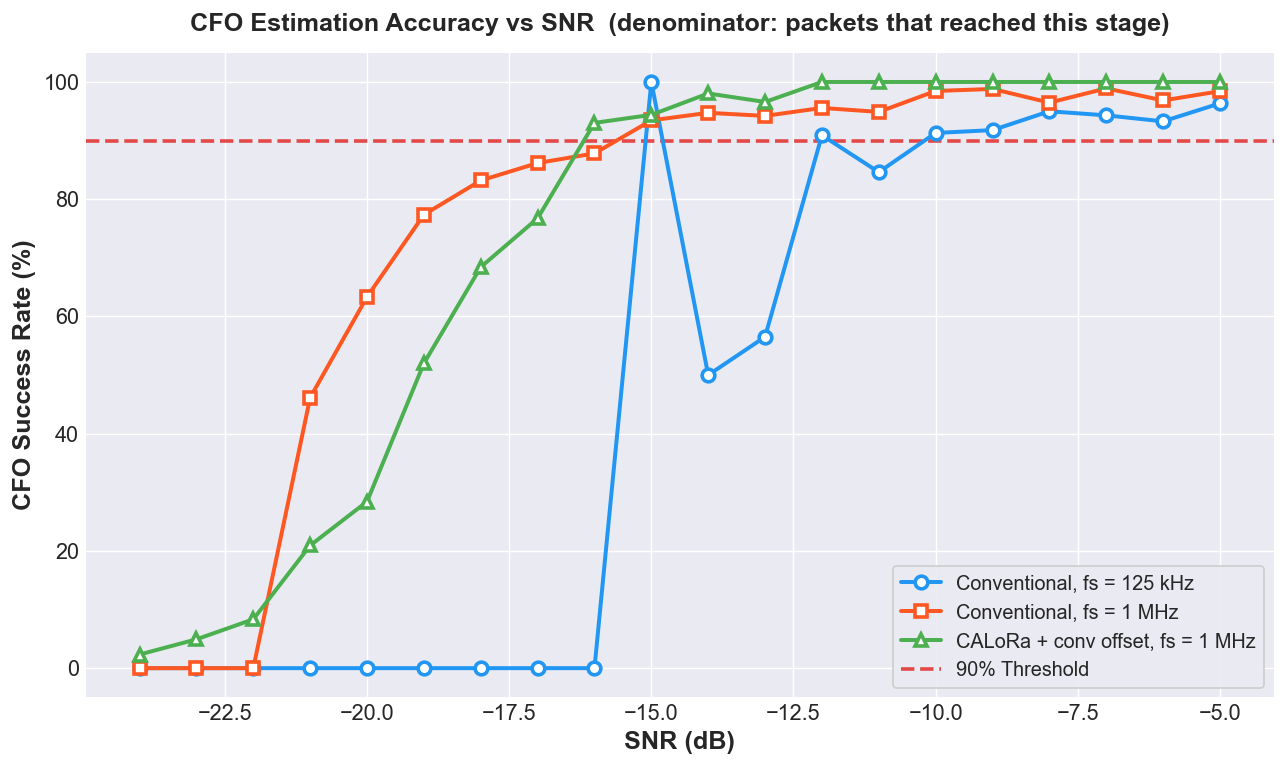


Plot saved to .\temp_results\acc_cfo_conditioned.png


In [64]:
plot_accuracy(
    'cfo',
    ylabel='CFO Success Rate (%)',
    title='CFO Estimation Accuracy vs SNR',
    outfile=f'acc_cfo_{ACC_SCOPE}.png',
)

## Symbol decoding accuracy vs SNR

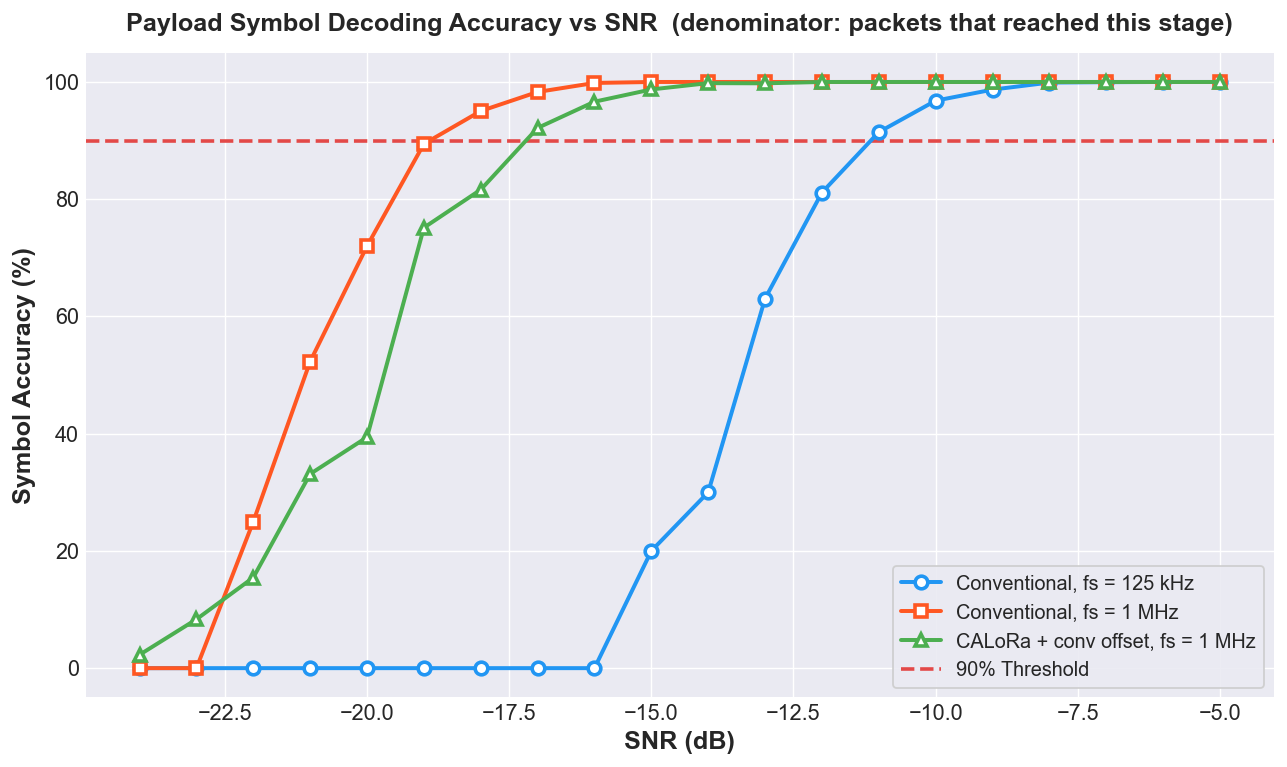


Plot saved to .\temp_results\acc_symbol_conditioned.png


In [65]:
plot_accuracy(
    'sym',
    ylabel='Symbol Accuracy (%)',
    title='Payload Symbol Decoding Accuracy vs SNR',
    outfile=f'acc_symbol_{ACC_SCOPE}.png',
)